# Quantização de imagens em tons de cinza

Nesta atividade, partindo do notebook desenvolvido em sala (leitura de imagem com OpenCV, conversão de espaços de cor e exibição com Matplotlib), vamos:

1. Carregar uma imagem e convertê-la para tons de cinza;
2. Gerar versões quantizadas dessa imagem em 1, 2, 4 e 8 bits (2, 4, 16 e 256 níveis de intensidade), implementando a quantização manualmente com NumPy (sem função pronta);
3. Exibir a imagem original em cinza e as quatro versões quantizadas em uma única figura;
4. Discutir o efeito da redução de bits sobre detalhes e transições de intensidade.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


## 1. Carregando a imagem escolhida

Se estiver rodando no Google Colab e quiser usar sua própria foto, descomente e execute a célula abaixo para fazer o upload; em seguida, ajuste o nome do arquivo em `cv2.imread`. Para este notebook, foi usada a imagem `astronauta.jpg`.

In [2]:
# from google.colab import files
# arquivo = files.upload()


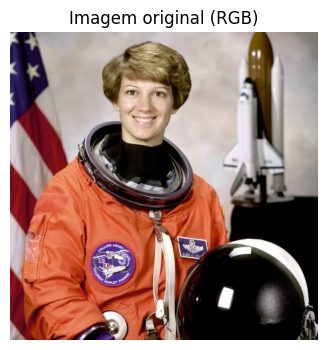

In [3]:
img_bgr = cv2.imread('astronauta.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) #convertendo bgr para rgb, so para exibicao

plt.figure(figsize=(4,4))
plt.imshow(img_rgb)
plt.title('Imagem original (RGB)')
plt.axis('off')
plt.show()


## 2. Convertendo para tons de cinza

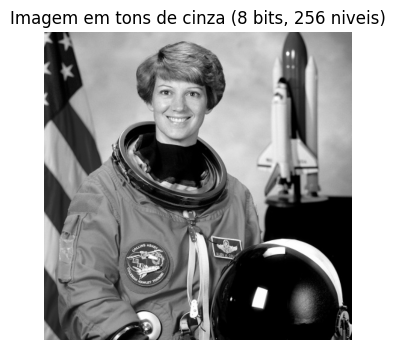

In [4]:
img_grey = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) #convertendo bgr para cinza

plt.figure(figsize=(4,4))
plt.imshow(img_grey, cmap='gray')
plt.title('Imagem em tons de cinza (8 bits, 256 niveis)')
plt.axis('off')
plt.show()


## 3. Quantização manual com NumPy

A imagem em tons de cinza já vem com 8 bits por pixel, ou seja, 256 níveis de intensidade possíveis (0 a 255). Para simular uma quantização com menos bits, dividimos essa faixa em um número menor de níveis igualmente espaçados.

Para `bits` bits, o número de níveis é `2**bits`. O tamanho de cada nível (passo) é `256 / niveis`. Cada pixel é então mapeado para o nível a que pertence, usando apenas operações aritméticas com o array NumPy (divisão, `floor` e multiplicação) — sem usar nenhuma função pronta de quantização.

In [5]:
def quantizar(img, bits):
    """Quantiza uma imagem em tons de cinza (0-255) para 2**bits niveis de intensidade,
    usando apenas operacoes com os valores dos pixels via NumPy."""
    niveis = 2 ** bits
    passo = 256 / niveis          # largura de cada faixa de intensidade

    indice_nivel = np.floor(img.astype(np.float64) / passo)   # a qual nivel (0..niveis-1) o pixel pertence
    indice_nivel = np.clip(indice_nivel, 0, niveis - 1)

    img_quant = (indice_nivel * passo).astype(np.uint8)       # volta para a escala 0-255
    return img_quant


bits_testados = [1, 2, 4, 8]
imagens_quantizadas = {bits: quantizar(img_grey, bits) for bits in bits_testados}


## 4. Exibindo original + quantizadas em uma única figura

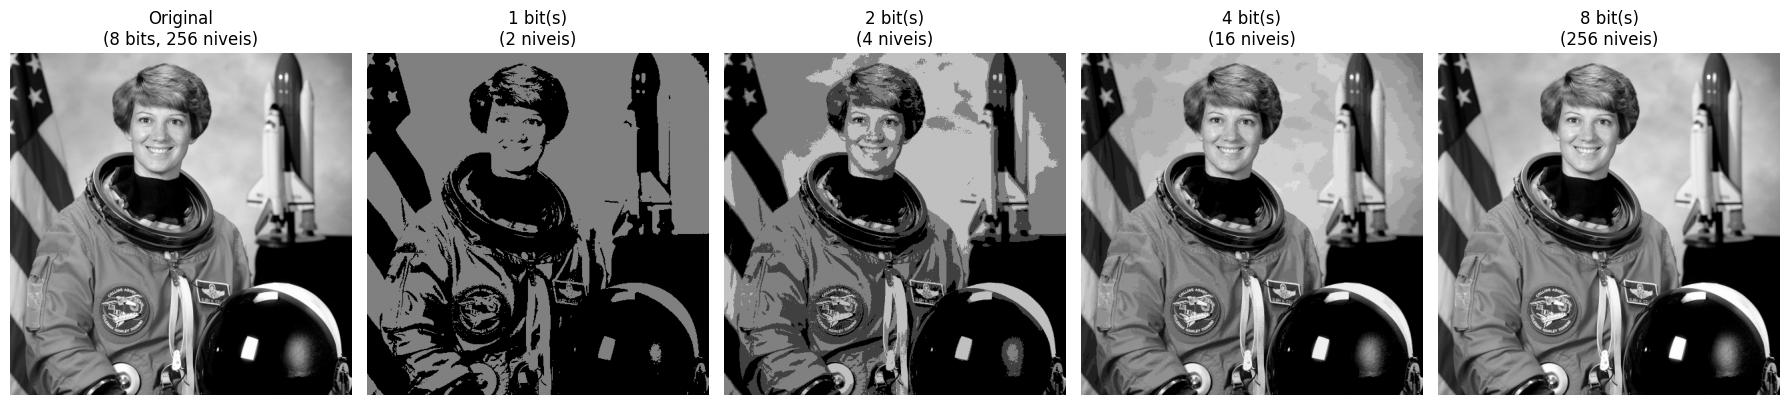

In [6]:
fig, ax = plt.subplots(1, 5, figsize=(18, 4))

ax[0].imshow(img_grey, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original\n(8 bits, 256 niveis)')
ax[0].axis('off')

for i, bits in enumerate(bits_testados, start=1):
    niveis = 2 ** bits
    ax[i].imshow(imagens_quantizadas[bits], cmap='gray', vmin=0, vmax=255)
    ax[i].set_title(f'{bits} bit(s)\n({niveis} niveis)')
    ax[i].axis('off')

plt.tight_layout()
plt.savefig('quantizacao.png', dpi=150)
plt.show()


## 5. Discussão

**O que acontece com os detalhes e com as transições de intensidade da imagem à medida que reduzimos o número de bits?**

Conforme o número de bits diminui, o número de níveis de cinza disponíveis cai drasticamente (256 → 16 → 4 → 2), e cada faixa de intensidade original passa a ser representada por um único valor. Isso tem dois efeitos principais:

- **Perda de detalhes finos**: regiões da imagem que antes tinham variações sutis de brilho (texturas, sombras suaves, gradientes) passam a ser "achatadas" em um mesmo tom, já que pixels com valores originais próximos acabam caindo no mesmo nível quantizado. Com 1 bit, por exemplo, a imagem vira essencialmente um recorte binário (preto/branco), onde só a silhueta geral e o contraste mais forte sobrevivem.
- **Transições abruptas (posterização)**: as transições suaves de intensidade (degradês) dão lugar a contornos em degrau bem visíveis — o efeito de *banding*/posterização. Em vez de uma mudança gradual de tom, aparecem blocos de intensidade constante separados por bordas nítidas, que não existiam na imagem original.

Em resumo, quanto menor o número de bits, menor a fidelidade tonal da imagem: ganha-se em economia de armazenamento/representação, mas perde-se granularidade nos detalhes e suavidade nas transições de intensidade.